# 06: LLM Explanation Layer

Converts per-applicant SHAP attributions into grounded plain-English risk
explanations. Probabilities quoted to humans come from the calibrated model
(`../models/xgb_calibrated.joblib`, see `05_calibration.ipynb`), never the
raw one.

The notebook starts with a feature correlation audit. SHAP splits credit
arbitrarily between features that carry overlapping information, and a
narrated explanation built on arbitrarily split credit can contradict
itself. The audit determines which features need grouped treatment in the
glossary and prompt before any explanation is generated.

In [1]:
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import shap
from scipy.stats import spearmanr

c:\Users\ohrac\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Correlation audit

Spearman rank correlation is used instead of Pearson because the count
features are heavily skewed (a majority of zeros with a long tail).
Pearson is distorted by the extreme values, while Spearman only asks
whether high values in one feature accompany high values in the other.

In [2]:
X_train = pd.read_csv('../data/processed/X_train.csv', index_col=0)

                                      NumberOfTime30-59DaysPastDueNotWorse  \
NumberOfTime30-59DaysPastDueNotWorse                                 1.000   
NumberOfTimes90DaysLate                                              0.240   
NumberOfTime60-89DaysPastDueNotWorse                                 0.267   

                                      NumberOfTimes90DaysLate  \
NumberOfTime30-59DaysPastDueNotWorse                    0.240   
NumberOfTimes90DaysLate                                 1.000   
NumberOfTime60-89DaysPastDueNotWorse                    0.298   

                                      NumberOfTime60-89DaysPastDueNotWorse  
NumberOfTime30-59DaysPastDueNotWorse                                 0.267  
NumberOfTimes90DaysLate                                              0.298  
NumberOfTime60-89DaysPastDueNotWorse                                 1.000  


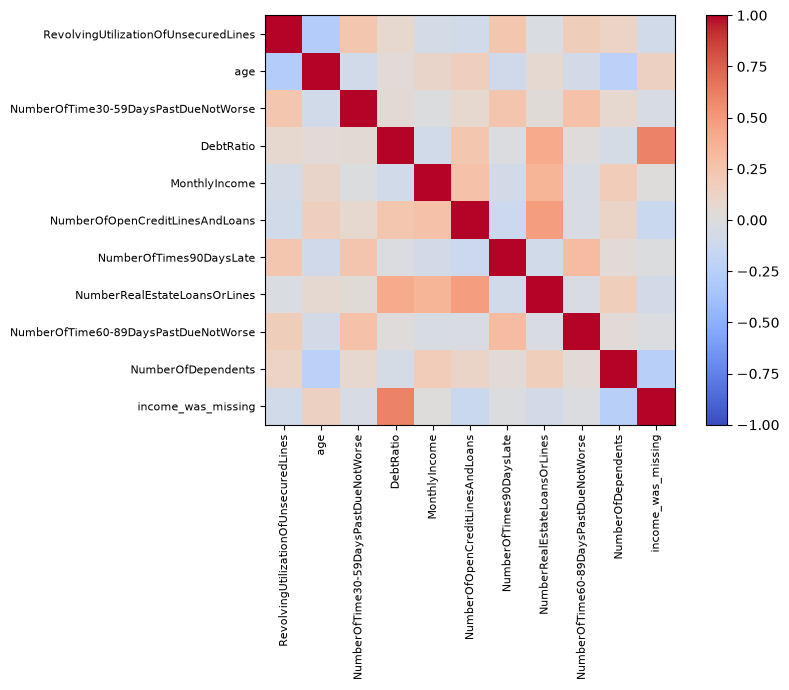

In [3]:
corr = X_train.corr(method='spearman')

past_due_cols = [
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTimes90DaysLate',
    'NumberOfTime60-89DaysPastDueNotWorse',
]
print(corr.loc[past_due_cols, past_due_cols].round(3))

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr, vmin=-1, vmax=1, cmap='coolwarm')
ax.set_xticks(range(len(corr))), ax.set_xticklabels(corr.columns, rotation=90, fontsize=8)
ax.set_yticks(range(len(corr))), ax.set_yticklabels(corr.columns, fontsize=8)
fig.colorbar(im)
plt.tight_layout()
plt.show()

The three past-due correlations are modest (0.24 to 0.30), but ~84% of
applicants have zero delinquencies in every tier, and that zero-inflation
dampens rank correlations. A binary co-occurrence check (ever-late vs
never-late per tier) measures the shared signal without the dilution.

In [4]:
d30 = (X_train['NumberOfTime30-59DaysPastDueNotWorse'] > 0)
d60 = (X_train['NumberOfTime60-89DaysPastDueNotWorse'] > 0)
d90 = (X_train['NumberOfTimes90DaysLate'] > 0)

tier_pairs = [
    ('30-59 late', d30, '60-89 late', d60),
    ('30-59 late', d30, '90+ late', d90),
    ('60-89 late', d60, '90+ late', d90),
]

for name_a, a, name_b, b in tier_pairs:
    p_given = b[a].mean()
    p_not = b[~a].mean()
    print(f"P({name_b} | {name_a}) = {p_given:.3f}   "
          f"P({name_b} | no {name_a}) = {p_not:.3f}   "
          f"lift = {p_given / p_not:.1f}x")

P(60-89 late | 30-59 late) = 0.176   P(60-89 late | no 30-59 late) = 0.025   lift = 6.9x
P(90+ late | 30-59 late) = 0.174   P(90+ late | no 30-59 late) = 0.032   lift = 5.5x
P(90+ late | 60-89 late) = 0.346   P(90+ late | no 60-89 late) = 0.039   lift = 8.9x


**Finding: related but not redundant.** All three delinquency tiers
travel together, with lifts of 6.9x (30-59 -> 60-89), 5.5x (30-59 -> 90+),
and 8.9x (60-89 -> 90+). The absolute rates stay far from redundancy.
Even in the tightest pair, 65% of applicants with a 60-89 day delinquency
never reach 90+ days, so each tier carries distinct signal.

**Decision:** SHAP values stay per-feature (no summing, the features are
not redundant). In the explanation layer the three are presented as one
family, "payment delinquency history", and the prompt forbids contrasting
severity tiers against each other, which prevents nonsense phrasing like
"90-day lateness raised risk while 60-89 day lateness lowered it".

### Full-matrix scan

The same credit-splitting concern applies to any correlated pair, so the
strongest pairs across the whole matrix are extracted rather than
eyeballed off the heatmap.

In [5]:
corr_abs = corr.abs()
top_pairs = (
    corr_abs.where(~np.eye(len(corr_abs), dtype=bool))
    .stack()
    .sort_values(ascending=False)
)
print(top_pairs.drop_duplicates().head(10).round(3))

DebtRatio                             income_was_missing                      0.603
NumberOfOpenCreditLinesAndLoans       NumberRealEstateLoansOrLines            0.471
NumberRealEstateLoansOrLines          DebtRatio                               0.401
MonthlyIncome                         NumberRealEstateLoansOrLines            0.348
NumberOfTimes90DaysLate               NumberOfTime60-89DaysPastDueNotWorse    0.298
RevolvingUtilizationOfUnsecuredLines  age                                     0.277
MonthlyIncome                         NumberOfOpenCreditLinesAndLoans         0.272
NumberOfTime60-89DaysPastDueNotWorse  NumberOfTime30-59DaysPastDueNotWorse    0.267
income_was_missing                    NumberOfDependents                      0.242
NumberOfTime30-59DaysPastDueNotWorse  NumberOfTimes90DaysLate                 0.240
dtype: float64


**Finding:** one pair crosses 0.5. `DebtRatio` and `income_was_missing`
correlate at 0.603, consistent with the EDA finding that extreme DebtRatio
values are overwhelmingly rows with undisclosed income (a broken-denominator
artifact, see `01_eda.ipynb`). The two features are partly two views of the
same underlying fact: income information is unreliable for this applicant.
`NumberOfOpenCreditLinesAndLoans` and `NumberRealEstateLoansOrLines` sit
just under the line at 0.471, correlated by construction since real estate
lines are a subset of total open lines. Notably, `DebtRatio` and
`MonthlyIncome` do not appear in the top pairs despite the denominator
link. Median imputation of the ~20% missing incomes and the artifact rows
largely broke that mechanical relationship.

**Decision: three narrative families, no SHAP summing.**
1. Payment delinquency history: the three past-due tiers.
2. Income reliability: `DebtRatio` + `income_was_missing`. When SHAP
   assigns credit to both for the same applicant, the explanation must
   treat them as one theme, not two independent pieces of evidence.
3. Credit portfolio size: `NumberOfOpenCreditLinesAndLoans` +
   `NumberRealEstateLoansOrLines`, with glossary entries noting the
   subset relationship.

The prompt forbids contrasting features within the same family. All other
pairs are 0.4 or below and need no special handling.

## Per-applicant SHAP extraction

The shipping model (`xgb_calibrated`) is a 5-fold calibrated ensemble that
`shap.TreeExplainer` cannot wrap directly. Contributions are therefore
computed on the raw `xgb_model` while the probability quoted to a human
always comes from the calibrated model. This split is valid because
isotonic calibration never reorders applicants. As a direct check, the
rank correlation between raw and calibrated scores on the demo pool is
0.997, so the two models order applicants near-identically and factor
attributions transfer.

SHAP values here are in the model's internal log-odds units, not
probability points. They are used for ranking, direction, and relative
magnitude of factors only, and are never presented as percentage effects.

The demo pool is the held-out test split, loaded without labels. Rows
serve as example applicants, not as evaluation data.

In [6]:
X_demo = pd.read_csv('../data/processed/X_test.csv', index_col=0)

xgb_model = joblib.load('../models/xgb_model.joblib')
xgb_cal = joblib.load('../models/xgb_calibrated.joblib')

explainer = shap.TreeExplainer(xgb_model)

raw_scores = xgb_model.predict_proba(X_demo)[:, 1]
cal_scores = xgb_cal.predict_proba(X_demo)[:, 1]
rho, _ = spearmanr(raw_scores, cal_scores)
print(f"Rank correlation, raw vs calibrated: {rho:.4f}")

Rank correlation, raw vs calibrated: 0.9972


In [7]:
def explain_applicant(row, top_k=5):
    shap_row = explainer.shap_values(row.to_frame().T)[0]
    risk = float(xgb_cal.predict_proba(row.to_frame().T)[0, 1])

    contributions = pd.Series(shap_row, index=row.index)
    top = contributions.reindex(contributions.abs().sort_values(ascending=False).index)[:top_k]

    return {
        "calibrated_risk": round(risk, 3),
        "top_factors": [
            {"feature": name, "shap": round(float(s), 3), "value": float(row[name])}
            for name, s in top.items()
        ],
    }

Three fixed test applicants cover the interesting cases: the safest in
the pool, one at the 0.060 decision threshold, and the riskiest. The same
trio is reused for every prompt iteration so output changes can be
attributed to prompt changes.

In [8]:
cases = {
    "low": cal_scores.argmin(),
    "borderline": abs(cal_scores - 0.06).argmin(),
    "high": cal_scores.argmax(),
}

for name, idx in cases.items():
    print(f"--- {name} risk (row {idx}) ---")
    print(json.dumps(explain_applicant(X_demo.iloc[idx]), indent=2))

--- low risk (row 357) ---
{
  "calibrated_risk": 0.0,
  "top_factors": [
    {
      "feature": "RevolvingUtilizationOfUnsecuredLines",
      "shap": -1.397,
      "value": 0.001846012
    },
    {
      "feature": "age",
      "shap": -1.147,
      "value": 95.0
    },
    {
      "feature": "DebtRatio",
      "shap": -0.397,
      "value": 0.0
    },
    {
      "feature": "NumberOfOpenCreditLinesAndLoans",
      "shap": -0.378,
      "value": 2.0
    },
    {
      "feature": "NumberOfTime30-59DaysPastDueNotWorse",
      "shap": -0.358,
      "value": 0.0
    }
  ]
}
--- borderline risk (row 11151) ---
{
  "calibrated_risk": 0.06,
  "top_factors": [
    {
      "feature": "RevolvingUtilizationOfUnsecuredLines",
      "shap": 0.842,
      "value": 0.9999999
    },
    {
      "feature": "NumberOfTimes90DaysLate",
      "shap": -0.336,
      "value": 0.0
    },
    {
      "feature": "NumberOfTime30-59DaysPastDueNotWorse",
      "shap": -0.309,
      "value": 0.0
    },
    {
      "

**Finding: isotonic tails claim certainty the evidence cannot support.**
The extreme demo applicants come back with calibrated risks of exactly
0.0 and 1.0. Isotonic calibration flattens to the observed rate of its
most extreme training bins, and validation counts above a calibrated
score of ~0.6 are thin (14 to 33 people per bucket in `05_calibration`),
so point estimates out there are not defensible, let alone certainty.

**Decision: displayed probabilities are clamped at the display layer,
not in the model.** Below 1% reads "below 1%", above 60% reads "above
60%", justified by where validation evidence runs out. Internal values
stay unclamped, so thresholding at 0.060 is unaffected. The explanation
layer also never uses prediction language ("will default"). It states
risk levels only.

In [9]:
def format_risk(risk):
    if risk < 0.01:
        return "below 1%"
    if risk > 0.60:
        return "above 60%, the highest range the model can reliably distinguish"
    return f"approximately {risk:.0%}"

for name, idx in cases.items():
    risk = explain_applicant(X_demo.iloc[idx])["calibrated_risk"]
    print(f"{name}: raw value {risk} -> displayed as: {format_risk(risk)}")

low: raw value 0.0 -> displayed as: below 1%
borderline: raw value 0.06 -> displayed as: approximately 6%
high: raw value 1.0 -> displayed as: above 60%, the highest range the model can reliably distinguish


## Prompt assembly

The template carries the fixed rules. Assembly fills its three slots per
applicant: glossary definitions for the features that fired (with each
family's note included once), the clamped risk display string, and the
top factors with direction and applicant values.

In [12]:
GLOSSARY = json.load(open('../prompts/feature_glossary.json'))
TEMPLATE = open('../prompts/explain_template.txt').read()

FEATURE_INFO = {}
for fam in GLOSSARY['families']:
    for feat in fam['features']:
        FEATURE_INFO[feat['feature']] = {**feat, 'family': fam['name'], 'family_note': fam['note']}


def build_prompt(explanation):
    factors = explanation['top_factors']

    fam_order, fam_members = [], {}
    for f in factors:
        fam = FEATURE_INFO[f['feature']]['family']
        if fam not in fam_members:
            fam_order.append(fam)
            fam_members[fam] = []
        fam_members[fam].append(f['feature'])

    lines = []
    for fam in fam_order:
        note = FEATURE_INFO[fam_members[fam][0]]['family_note']
        lines.append(f"FAMILY: {fam}. {note}")
        for name in fam_members[fam]:
            info = FEATURE_INFO[name]
            lines.append(f"- {name}: {info['definition']} "
                         f"High values: {info['high_value_means']}")
    definitions = "\n".join(lines)

    factor_lines = "\n".join(
        f"- {f['feature']}: score {f['shap']:+.2f}, applicant value {f['value']:g}"
        for f in factors
    )

    return TEMPLATE.format(
        definitions=definitions,
        risk_display=format_risk(explanation['calibrated_risk']),
        factors=factor_lines,
    )

In [13]:
print(build_prompt(explain_applicant(X_demo.iloc[cases['high']])))

You write credit risk explanations for loan applicants. You will be given
an applicant's estimated risk, the factors that influenced their score,
and vetted definitions of those factors. Write a short explanation
(3-5 sentences) of their assessment in plain, neutral language that
non-technical audience can udnerstand.

RULES:
1. Only state facts present in the FACTORS and DEFINITIONS sections.
   Never add reasons, numbers, or advice that are not given to you.
2. State the risk exactly as given in ESTIMATED RISK. Never restate it
   as a different number or convert factor scores into percentages.
3. Factor scores indicate direction and relative strength only. Describe
   stronger factors as mattering more. Never quote the scores themselves.
4. Features listed under the same FAMILY describe one topic. Mention the
   family's overall effect once. Never contrast family members against
   each other.
5. Use risk language ("estimated risk", "associated with"), never
   prediction language (